# **Monty Hall Problem**

1. There are three closed doors. Behind one door is a car (the prize); behind the other two
are goats.
2. You select one door (e.g., Door 1).
3. The host (who knows exactly what is behind every door) must open one of the remaining
two doors.
4. The host will never open the door with the car, and will never open your selected door.
The host reveals a goat.
5. The host then offers you a choice: “Do you want to stay with your original door, or switch
to the remaining closed door?”

![Screenshot 2026-08-11 092548.png](<attachment:Screenshot 2026-08-11 092548.png>)
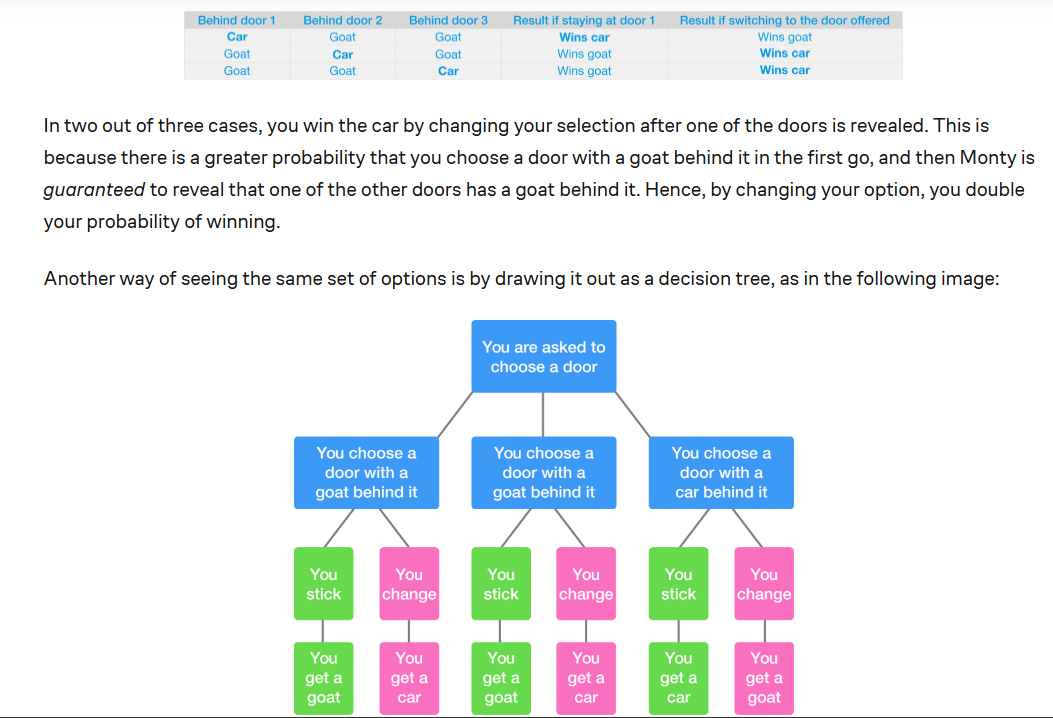

![Screenshot 2026-08-11 092052.png](<attachment:Screenshot 2026-08-11 092052.png>)
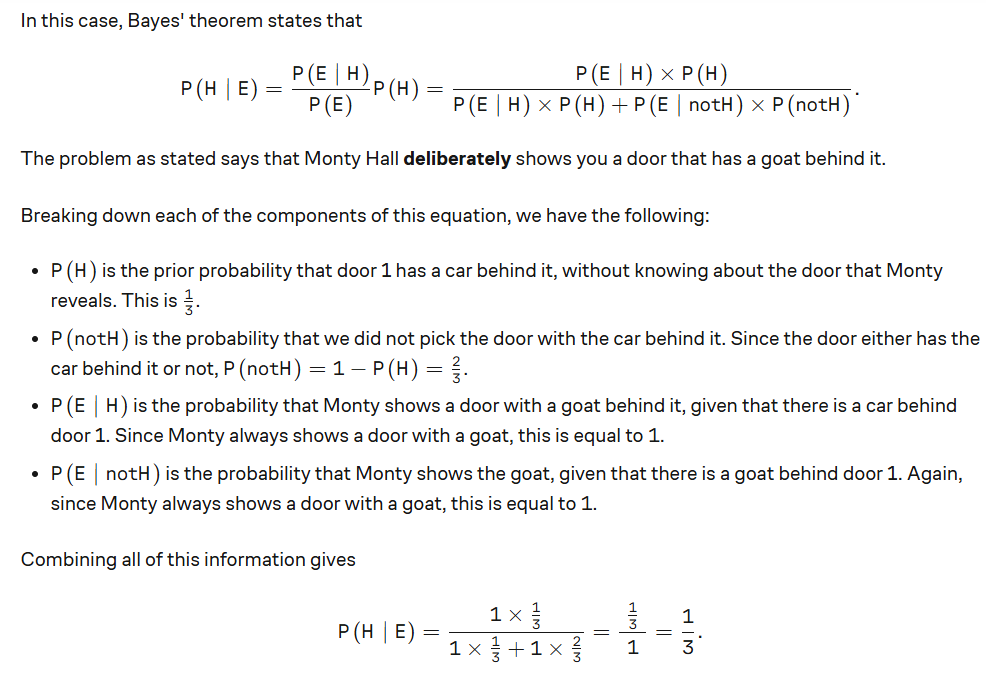

You must empirically verify whether switching is the dominant strategy.
* Write a Python simulation that plays this game 10, 000 times.
* In each trial, randomly assign the car to a door, randomly select an initial door, explicitly
enforce the host’s logic to open a valid goat door, and determine the outcome if you stay
versus if you switch.
* Calculate and print the empirical probability of winning for both the “Stay” and “Switch”
strategies.

In [1]:
import random

In [12]:
trials = 10000
stay_wins = 0
switch_wins = 0
doors = [0, 1, 2]

for _ in range(trials):

    # 1. Randomly place the car
    car = random.choice(doors)
    print(f"Car is behind door: {car}")  # Debugging line to see where the car is placed

    # 2. Randomly select the initial door
    choice = random.choice(doors)
    print(f"Player's initial choice: {choice}")  # Debugging line to see the player's initial choice

    # 3. Host opens a valid goat door
    possible_goat_doors = [door for door in doors if door != choice and door != car]
    print(f"Possible goat doors: {possible_goat_doors}")  # Debugging line to see possible goat doors

    host_opens = random.choice(possible_goat_doors)
    print(f"Host opens door: {host_opens}")  # Debugging line to see which door the host opens

    # 4. The remaining closed door
    switch_choice = [door for door in doors if door != choice and door != host_opens][0]
    print(f"Player switches to door: {switch_choice}")  # Debugging line to see the player's switch choice

    # 5. Check Stay strategy
    if choice == car:
        stay_wins += 1

    # 6. Check Switch strategy
    if switch_choice == car:
        switch_wins += 1

# Calculate probabilities
stay_probability = stay_wins / trials
switch_probability = switch_wins / trials

print("Total trials:", trials)
print("Stay wins:", stay_wins)
print("Switch wins:", switch_wins)

print("Probability of winning by staying:", stay_probability)
print("Probability of winning by switching:", switch_probability)

Car is behind door: 2
Player's initial choice: 1
Possible goat doors: [0]
Host opens door: 0
Player switches to door: 2
Car is behind door: 1
Player's initial choice: 0
Possible goat doors: [2]
Host opens door: 2
Player switches to door: 1
Car is behind door: 2
Player's initial choice: 2
Possible goat doors: [0, 1]
Host opens door: 0
Player switches to door: 1
Car is behind door: 2
Player's initial choice: 1
Possible goat doors: [0]
Host opens door: 0
Player switches to door: 2
Car is behind door: 1
Player's initial choice: 0
Possible goat doors: [2]
Host opens door: 2
Player switches to door: 1
Car is behind door: 2
Player's initial choice: 0
Possible goat doors: [1]
Host opens door: 1
Player switches to door: 2
Car is behind door: 0
Player's initial choice: 0
Possible goat doors: [1, 2]
Host opens door: 2
Player switches to door: 1
Car is behind door: 1
Player's initial choice: 1
Possible goat doors: [0, 2]
Host opens door: 2
Player switches to door: 0
Car is behind door: 0
Player's 

It is observed that the probability of switching is more than the probability of staying.

# **Polya’s Urn**

1. Initialize an urn with r red balls and b black balls.
2. Draw a single ball at random and observe its color.
3. Return the drawn ball to the urn, and add c additional balls of the exact same color.
4. Repeat the process for N draws.

**Part A: Single Urn Trajectory**
* Write a function to simulate an urn starting with r = 1, b = 1, and c = 1. Simulate 1,000 draws.
* Plot a line graph showing the proportion of red balls on the y-axis versus the draw number on
the x-axis. Run it several times to see how early random fluctuations lock the urn into different
long-term states.

In [16]:
import random
import matplotlib.pyplot as plt


def simulate_urn(r=1, b=1, c=1, N=1000):

    red = r
    black = b

    red_proportions = []
    black_proportions = []

    for draw in range(1, N + 1):
        # Probability of drawing a red ball
        red_probability = red / (red + black)
        red_proportions.append(red_probability)
        black_probability = black / (red + black)
        black_proportions.append(black_probability)
        print("Red probability : ", red_probability)
        print("Black probability : ", black_probability)

        # Draw a ball
        if random.random() < red_probability:
            # Red was drawn
            print("Red is drawn")
            red += c
        else:
            # Black was drawn
            print("Black is drawn")
            black += c

    return red_proportions, black_proportions


# Simulate 1000 draws
red_proportions, black_proportions = simulate_urn(1, 1, 1, 1000)
print(red_proportions)  # Print the list of red proportions for debugging
print(black_proportions)  # Print the list of black proportions for debugging

print("Final red proportion:", red_proportions[-1])
print("Final black proportion:", black_proportions[-1])

Red probability :  0.5
Black probability :  0.5
Black is drawn
Red probability :  0.3333333333333333
Black probability :  0.6666666666666666
Red is drawn
Red probability :  0.5
Black probability :  0.5
Red is drawn
Red probability :  0.6
Black probability :  0.4
Black is drawn
Red probability :  0.5
Black probability :  0.5
Black is drawn
Red probability :  0.42857142857142855
Black probability :  0.5714285714285714
Red is drawn
Red probability :  0.5
Black probability :  0.5
Red is drawn
Red probability :  0.5555555555555556
Black probability :  0.4444444444444444
Red is drawn
Red probability :  0.6
Black probability :  0.4
Black is drawn
Red probability :  0.5454545454545454
Black probability :  0.45454545454545453
Red is drawn
Red probability :  0.5833333333333334
Black probability :  0.4166666666666667
Red is drawn
Red probability :  0.6153846153846154
Black probability :  0.38461538461538464
Red is drawn
Red probability :  0.6428571428571429
Black probability :  0.3571428571428571

It is observed that no matter which is the first ball, the probability of red ball is higher than black ball.

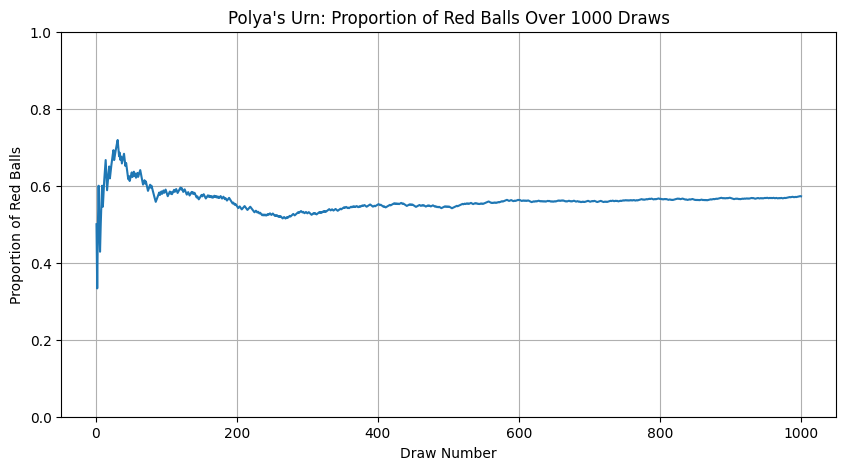

In [17]:
# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 1001),
    red_proportions
)

plt.xlabel("Draw Number")
plt.ylabel("Proportion of Red Balls")
plt.title("Polya's Urn: Proportion of Red Balls Over 1000 Draws")

plt.ylim(0, 1)
plt.grid(True)

plt.show()

**Part B: Limiting Behavior**
What is the probability distribution of the final proportion of red balls as N becomes very
large? 

To find out:
* Write a script to simulate 5,000 independent urns in parallel.
* Start each urn with 1 red and 1 black ball (c = 1). Simulate 1,000 draws for each.
* Record only the final proportion of red balls for each of the 5,000 urns.
* Plot a histogram (with 50 bins) of these final proportions.
* Question: Describe the shape of the histogram. Does the empirical distribution cluster
around 0.5 (50/50), or does it look different? What does this imply about the limiting
behavior of this specific belief model?
* Experiment with 5 different starting values of r and b and show how the histogram changes.

Final red proportion for urn 1: 0.30538922155688625
Final red proportion for urn 2: 0.9321357285429142
Final red proportion for urn 3: 0.9051896207584831
Final red proportion for urn 4: 0.7015968063872255
Final red proportion for urn 5: 0.8902195608782435
Final red proportion for urn 6: 0.9930139720558883
Final red proportion for urn 7: 0.6477045908183633
Final red proportion for urn 8: 0.49800399201596807
Final red proportion for urn 9: 0.250499001996008
Final red proportion for urn 10: 0.8562874251497006
Final red proportion for urn 11: 0.5678642714570858
Final red proportion for urn 12: 0.6806387225548902
Final red proportion for urn 13: 0.37924151696606784
Final red proportion for urn 14: 0.4441117764471058
Final red proportion for urn 15: 0.10578842315369262
Final red proportion for urn 16: 0.49800399201596807
Final red proportion for urn 17: 0.40219560878243515
Final red proportion for urn 18: 0.6187624750499002
Final red proportion for urn 19: 0.874251497005988
Final red proport

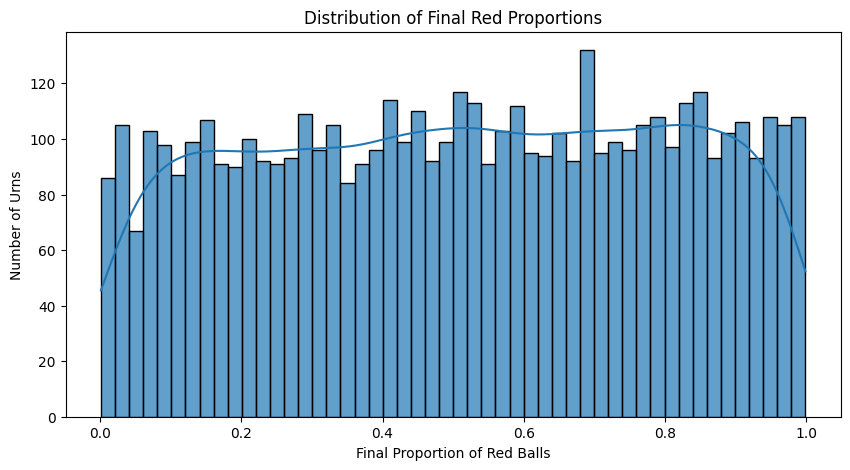

In [25]:
import random
import matplotlib.pyplot as plt
import seaborn as sns


def simulate_urn(r, b, c, N):
    for _ in range(N):
        red_probability = r / (r + b)
        if random.random() < red_probability:
            r += c
        else:
            b += c
    return r / (r + b)

num_urns = 5000
N = 1000
final_proportions = []

for _ in range(num_urns):
    final_red_proportion = simulate_urn(r=1,b=1,c=1,N=N)
    final_proportions.append(final_red_proportion)
    print(f"Final red proportion for urn {_ + 1}: {final_red_proportion}")  # Debugging line to see the final proportion for each urn

plt.figure(figsize=(10, 5))
sns.histplot(final_proportions, bins=50, kde=True, alpha=0.7)  # Added KDE for better visualization
plt.xlabel("Final Proportion of Red Balls")
plt.ylabel("Number of Urns")
plt.title("Distribution of Final Red Proportions")

plt.show()

The histogram shows the distribution of the final red proportions across 5,000 independent urns. It is spread over a wide range rather than being concentrated around 0.5. This shows that the Pólya urn model has a random limiting proportion, and early random fluctuations are reinforced over time.\

Why isn't it concentrated at 0.5?\
Because the process is self-reinforcing. If red is selected more often early, more red balls are added, making red more likely to be selected again. Different urns therefore develop different long-term proportions.\

What is the main takeaway?\
The initial 50/50 composition does not force the final composition to be 50/50. The final proportion depends on the random sequence of early draws.\

In [ ]:
def simulate_urn(r, b, c, N):
    for _ in range(N):
        red_probability = r / (r + b)
        if random.random() < red_probability:
            r += c
        else:
            b += c
    return r / (r + b)

num_urns = 5000
N = 1000
final_proportions = []

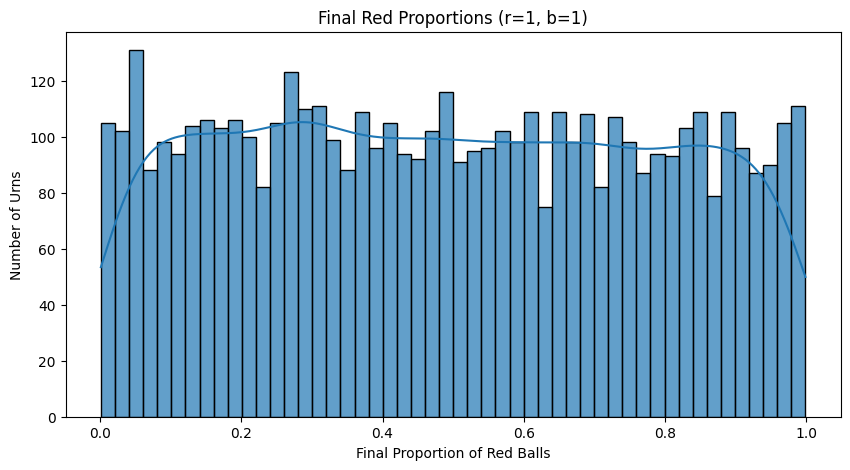

In [27]:
num_urns = 5000
N = 1000
final_proportions = []

for _ in range(num_urns):
    final_red_proportion = simulate_urn(r=1,b=1,c=1,N=N)
    final_proportions.append(final_red_proportion)
    
plt.figure(figsize=(10, 5))
sns.histplot(final_proportions, bins=50, kde=True, alpha=0.7)  # Added KDE for better visualization
plt.xlabel("Final Proportion of Red Balls")
plt.ylabel("Number of Urns")
plt.title(f"Final Red Proportions (r=1, b=1)")
plt.show()

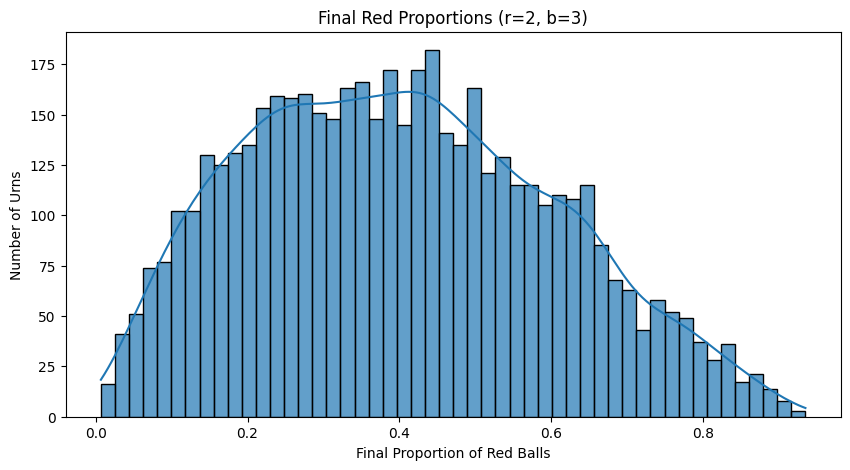

In [30]:
num_urns = 5000
N = 1000
final_proportions = []

for _ in range(num_urns):
    final_red_proportion = simulate_urn(r=2,b=3,c=1,N=N)
    final_proportions.append(final_red_proportion)
    
plt.figure(figsize=(10, 5))
sns.histplot(final_proportions, bins=50, kde=True, alpha=0.7)  # Added KDE for better visualization
plt.xlabel("Final Proportion of Red Balls")
plt.ylabel("Number of Urns")
plt.title(f"Final Red Proportions (r=2, b=3)")
plt.show()

It shows the distribution of final red proportions across many independent Pólya urns starting with 2 red and 3 black balls. Since the initial red proportion is 0.4, the distribution is centered around the lower-middle range, but randomness and reinforcement cause different urns to end at different proportions.

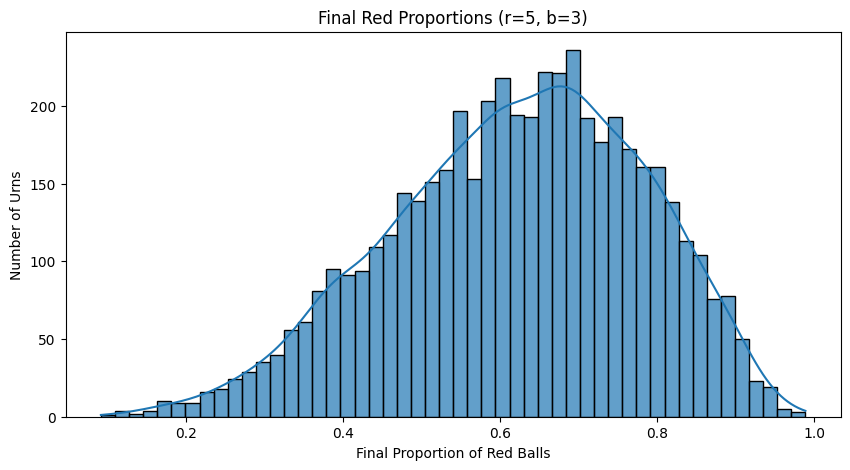

In [29]:
num_urns = 5000
N = 1000
final_proportions = []

for _ in range(num_urns):
    final_red_proportion = simulate_urn(r=5,b=3,c=1,N=N)
    final_proportions.append(final_red_proportion)
    
plt.figure(figsize=(10, 5))
sns.histplot(final_proportions, bins=50, kde=True, alpha=0.7)  # Added KDE for better visualization
plt.xlabel("Final Proportion of Red Balls")
plt.ylabel("Number of Urns")
plt.title(f"Final Red Proportions (r=5, b=3)")
plt.show()

Changing the starting values of r and b changes the distribution of the final red proportion. When the initial red proportion is higher, the distribution shifts toward higher red proportions. Also, having more initial balls reduces the effect of early random fluctuations, making the distribution more concentrated. This demonstrates the self-reinforcing nature of the Pólya urn model.\

Why is r=1,b=1 more spread out than r=5,b=3?\
Because with only two initial balls, each early draw has a large effect on the composition. With more initial balls, each individual addition has a smaller effect, so the final proportion is less variable.\

Why is r=5,b=3 shifted to the right?\
Because we start with more red balls than black balls, so the initial red proportion is 62.5%. The reinforcement mechanism tends to preserve this advantage, so the final red proportions tend to be higher.\

# **The SIR Model of Disease Spread**

Model Description (The Urn Analogy)
The SIR model tracks how an infectious disease spreads through a population over time. We
can conceptualize a population of size N as an urn containing N balls, where the color of each
ball represents an individual’s health status:
* S (Susceptible): Blue balls (healthy but vulnerable to infection).
* I (Infectious): Red balls (sick and contagious).
* R (Recovered): Green balls (recovered and permanently immune).

The disease dynamics operate via the following rules applied at each discrete time step (e.g.,
daily):
* Infection Mechanism: To model social contact, a blue ball interacts with another ball
drawn uniformly at random from the entire urn. If the second ball is red, there is a base
transmission probability β that the disease is transmitted, turning the blue ball red.
* Recovery Mechanism: Independent of interactions, every red ball in the urn has a
daily probability γ of recovering and permanently turning into a green ball.

**1. Mathematical Implementation** 

![Screenshot 2026-08-11 135244.png](<attachment:Screenshot 2026-08-11 135244.png>)
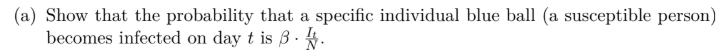

We have to find that - What is the probability that a specific susceptible person becomes infected on day t?

For a blue ball to become infected it must interact with infected person.

First we find the probability of infected people,
* There are It​ infectious people out of N people.
* Therefore, P(infected) = It/N

* The person has found a infected person, now the disease will transmit
* P(transmission) = beta

* P(getting infected) = P(infected) * P(transmission)
                    = beta*It/N

![Screenshot 2026-08-11 135254.png](<attachment:Screenshot 2026-08-11 135254.png>)
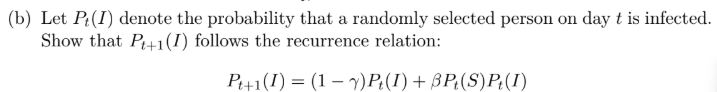

Given, P[t](I) = P(infected) \
P[t+1](I) = ? \

A person is infected on day t, \
how will he remain infected? \
- Either person will not recover \
- or non infected will get infected  \

P(person will not recover) = (1 - gamma)P[t](I) \
where, gamma is the recovering probability of (1 - gamma) is not recovering probability \
and a infected person is selected so probability of selecting infected person is also added. \

P(suseptible gets infected) = (beta)(P[t](I))(P[t](S)) \
where, beta is the probability of person getting infected \
and person gets infected when he gets in contact with infected so we multiply P(I) \
and we are selecting a suseptible function so we add P(S) \

Overall probability,\
P(person is infectednext day) = P(infected person will not recover) + P(suseptible gets infected)\
P[t+1](I) = (1 - gamma)P[t](I) + (beta)(P[t](I))(P[t](S))\

![Screenshot 2026-08-11 135307.png](<attachment:Screenshot 2026-08-11 135307.png>)

P(t+1)(S) = P(person is suseptible next day)\
P(t+1)(R) = P(person is recovered next day)\

For first,\
Cases:\
1. person is already suseptible
2. person doesn't meet infected person\
So, out of all the suseptible we remove the people that meet infected people\
P(person is susteptible next day) = P(suseptible on that day) - P(people who meet infected people)\
P(t+1)(S) = P(t)(S) - (beta)(P(t)(I))(P(t)(S))\

For second,\
Cases:\
1. person is already recovered
2. infected person is recovered\
P(person is recovered next day) = P(person is recovered this day) + P(infected is recovered)\
P(t+1)(R) = P(t)(R) + (gamma)P(t)(I)\

**Empirical Verification:** 
Implement a discrete-time SIR simulation in Python that di-
rectly models the urn mechanics. At each time step (day), for every blue ball, simulate
drawing a random ball from the urn and apply the infection probability β if a red ball
is drawn. For every red ball, simulate a coin flip with probability γ to determine if it
recovers. Set the initial parameters to: N = 10, 000, Initial Infected (I0) = 10, Initial
Recovered (R0) = 0. Simulate for 150 days and plot S, I, and R curves on a single graph.
Overlay the expected trajectories calculated from your mathematical recurrence formulas
to verify that the empirical urn simulation aligns with your derivations.

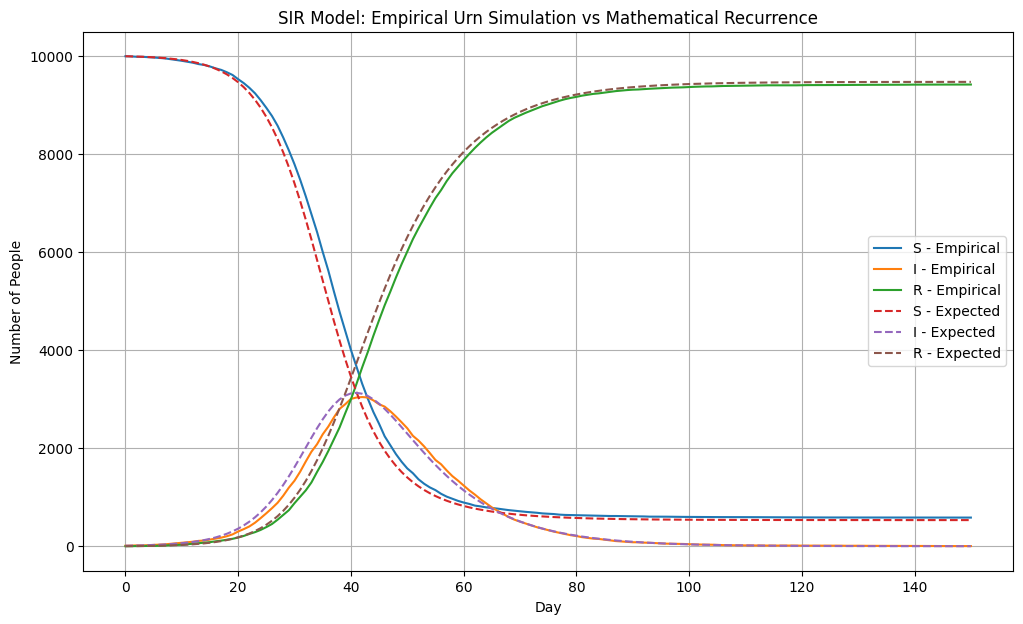

In [32]:
import random
import matplotlib.pyplot as plt

def sir_urn_simulation(N, I0, R0, beta, gamma, days):

    # Initial number of susceptible people
    S = N - I0 - R0
    I = I0
    R = R0

    # Store daily values
    S_history = [S]
    I_history = [I]
    R_history = [R]

    for day in range(days):
        # Keep the values at the beginning of the day
        old_S = S
        old_I = I
        old_R = R

        new_infections = 0
        new_recoveries = 0

        # Infection process
        # For every susceptible (blue) person,
        # randomly select one person from the population.
        for _ in range(old_S):
            # Randomly select a person from the population
            selected_person = random.randrange(N)
            # We represent the first old_I people as infectious.
            # Therefore, selected_person < old_I means
            # an infectious person was selected.
            if selected_person < old_I:
                # Transmission occurs with probability beta
                if random.random() < beta:
                    new_infections += 1

        # Recovery process
        # Every infectious person has probability
        # gamma of recovering.
        for _ in range(old_I):
            if random.random() < gamma:
                new_recoveries += 1

        # Update the population
        S = old_S - new_infections
        I = old_I + new_infections - new_recoveries
        R = old_R + new_recoveries

        S_history.append(S)
        I_history.append(I)
        R_history.append(R)

    return S_history, I_history, R_history

# DETERMINISTIC SIR MODEL
# Mathematical recurrence
def sir_deterministic(N, I0, R0, beta, gamma, days):

    # Convert population counts into probabilities
    S = (N - I0 - R0) / N
    I = I0 / N
    R = R0 / N
    S_history = [S * N]
    I_history = [I * N]
    R_history = [R * N]

    for day in range(days):
        # New infections
        new_infections = beta * S * I
        # New recoveries
        new_recoveries = gamma * I
        # Recurrence relations
        S = S - new_infections
        I = I + new_infections - new_recoveries
        R = R + new_recoveries

        S_history.append(S * N)
        I_history.append(I * N)
        R_history.append(R * N)

    return S_history, I_history, R_history

# PARAMETERS
N = 10000
I0 = 10
R0 = 0
beta = 0.3
gamma = 0.1
days = 150

# RUN EMPIRICAL SIMULATION
S_sim, I_sim, R_sim = sir_urn_simulation(N, I0, R0, beta, gamma, days)

# RUN MATHEMATICAL MODEL
S_expected, I_expected, R_expected = sir_deterministic(N, I0, R0, beta, gamma, days)

# PLOT BOTH
plt.figure(figsize=(12, 7))

# Empirical simulation = solid lines
plt.plot(S_sim, label="S - Empirical")
plt.plot(I_sim, label="I - Empirical")
plt.plot(R_sim, label="R - Empirical")

# Mathematical expectation = dashed lines
plt.plot(S_expected, "--", label="S - Expected")
plt.plot(I_expected, "--", label="I - Expected")
plt.plot(R_expected, "--", label="R - Expected")

plt.xlabel("Day")
plt.ylabel("Number of People")

plt.title(
    "SIR Model: Empirical Urn Simulation vs Mathematical Recurrence"
)

plt.legend()
plt.grid(True)

plt.show()

**Analysis Subquestions**\
Once your simulation is verified, modify your code to answer the following:
1. Analyzing the Baseline: Using β = 0.3 and γ = 0.1, on approximately what day does
the infection peak? At that peak, roughly how many people are concurrently infected?
2. Flattening the Curve: Social distancing reduces the probability of transmission. Lower
β from 0.3 to 0.15. How does this change the peak and the overall shape of the infectious
curve?
3. Medical Intervention: Assume a new treatment helps people recover faster. Keep
β = 0.3 but increase γ from 0.1 to 0.2. Compare this peak to the baseline peak.
4. The Threshold of Spread: Set β = 0.1 and γ = 0.1. What happens to the “Infectious”
curve? Explain logically why an epidemic fails to take off under these conditions.
5. Simulating Vaccination: Modify your initialization so that V0 (initial vaccinated peo-
ple) start in the R (Green ball) category. Let N = 10, 000, β = 0.4, and γ = 0.1. Write a loop to run the deterministic simulation while varying V0 from 0 to 9, 900 in increments
of 100. For each iteration, record the peak number of concurrent infections. Generate a
plot with the Initial Vaccinated Population (V0) on the x-axis and the Peak Infections on 3 the y-axis. Observe the relationship.

Note: Using the recurrence relations instead of running the full simulation will be benefi-
cial here.

In [ ]:
# the same function will be used
def sir_deterministic(N, I0, R0, beta, gamma, days):
    S = N - I0 - R0
    I = I0
    R = R0
    S_history = [S]
    I_history = [I]
    R_history = [R]
    for day in range(days):
        # New infections
        new_infections = beta * S * I / N
        # New recoveries
        new_recoveries = gamma * I
        # SIR recurrence equations
        S = S - new_infections
        I = I + new_infections - new_recoveries
        R = R + new_recoveries
        S_history.append(S)
        I_history.append(I)
        R_history.append(R)
    return S_history, I_history, R_history

In [35]:
# Base
N = 10000
I0 = 10
R0 = 0
beta = 0.3
gamma = 0.1
days = 150

S, I, R = sir_deterministic(N, I0, R0, beta, gamma, days)
peak_infections = max(I)
peak_day = I.index(peak_infections)

print("Peak day:", peak_day)
print("Peak infections:", peak_infections)

Peak day: 41
Peak infections: 3127.3145113677656


The infection peaks at approximately day 41, with roughly 3,100 people concurrently infected.\

Why does it rise first?\
Initially there are:\
9990 Susceptible\
10 Infectious\
0 Recovered\

There are many susceptible people available to become infected.\
So: new infections > recoveries and I increases.\

Eventually, susceptible people become fewer, so new infections decrease.\
Then: new infections < recoveries and I starts decreasing.\

In [36]:
# Flattening the curve
beta = 0.15
gamma = 0.1

S, I, R = sir_deterministic(N, I0, R0, beta, gamma, days)

peak_infections = max(I)
peak_day = I.index(peak_infections)

print("Peak day:", peak_day)
print("Peak infections:", peak_infections)

Peak day: 116
Peak infections: 645.7819343831823


When beta is reduced from 0.3 to 0.15, transmission becomes slower. The peak number of infected people decreases significantly and the peak occurs later. The infectious curve becomes lower and flatter

In [37]:
# Medical intervention
beta = 0.3
gamma = 0.2

S, I, R = sir_deterministic(N, I0, R0, beta, gamma, days)

peak_infections = max(I)
peak_day = I.index(peak_infections)

print("Peak day:", peak_day)
print("Peak infections:", peak_infections)

Peak day: 59
Peak infections: 654.8211000822619


Increasing gamma means faster recovery. Therefore, infectious people leave the infectious group faster, so the peak number of concurrent infections becomes much smaller and occurs later

In [38]:
# Threshold of Spread
beta = 0.1
gamma = 0.1

S, I, R = sir_deterministic(N, I0, R0, beta, gamma, days)

peak_infections = max(I)
peak_day = I.index(peak_infections)

print("Peak day:", peak_day)
print("Peak infections:", peak_infections)

Peak day: 0
Peak infections: 10


The infectious curve starts with 10 infected people and does not increase above this initial value. Therefore, the maximum is 10 on day 0. The epidemic fails to take off because the transmission rate is not sufficient to overcome the recovery rate.

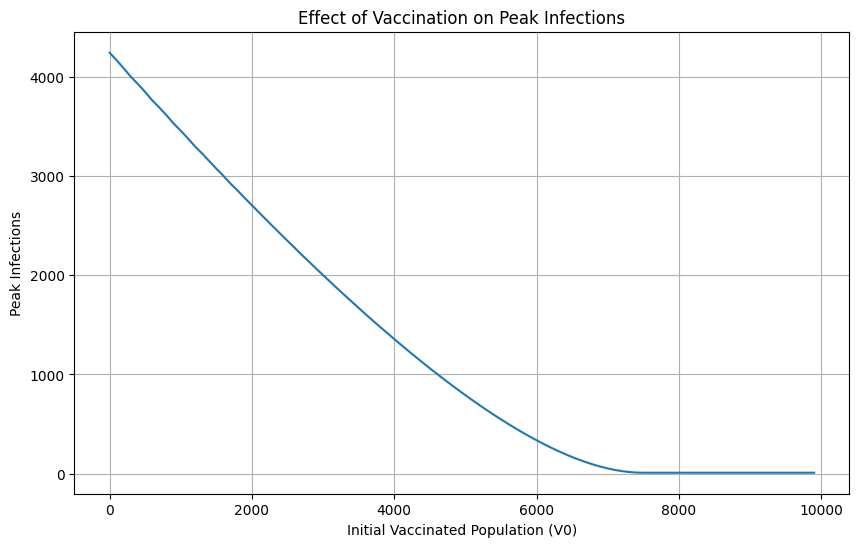

In [40]:
# Vaccination
import matplotlib.pyplot as plt
N = 10000
I0 = 10
beta = 0.4
gamma = 0.1
vaccination_values = range(0, 9901, 100)
peak_infections = []

for V0 in vaccination_values:
    # Vaccinated people are placed directly in R
    R0 = V0
    # Everyone else is susceptible, except the initial infected
    S0 = N - I0 - R0
    S = S0
    I = I0
    R = R0
    max_I = I
    # Deterministic SIR simulation
    for day in range(150):
        # Recurrence equations
        new_infections = beta * S * I / N
        new_recoveries = gamma * I
        S = S - new_infections
        I = I + new_infections - new_recoveries
        R = R + new_recoveries
        # Store the maximum number of infections
        if I > max_I:
            max_I = I
    peak_infections.append(max_I)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(
    vaccination_values,
    peak_infections
)
plt.xlabel("Initial Vaccinated Population (V0)")
plt.ylabel("Peak Infections")
plt.title("Effect of Vaccination on Peak Infections")
plt.grid(True)
plt.show()

Half of the population is already immune.
Therefore, there are fewer people available to become infected.